In [1]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-5-nano', temperature=0)

### **Step1: Define state/schema**

In [6]:
from typing import TypedDict

class GraphState(TypedDict):
    name: str
    message: str

### **Step2: Create Graph Node Function**


In [20]:
def greet(state:GraphState)->GraphState:
    name = state['name']
    message = state['message']

    response = llm.invoke(f"Hey my name is {name}. {message}").content
    state['message'] = f"This was your message: {message}. Here is my response: {response}"

    return state

### **Step3: Create Graph, node, edges**

In [21]:
from langgraph.graph import StateGraph, START, END

my_first_graph = StateGraph(GraphState)
my_first_graph.add_node("greet", greet)
my_first_graph.add_edge(START, "greet")
my_first_graph.add_edge("greet", END)


### **Step4: Complie your Graph**

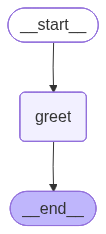

In [22]:
my_first_graph_compiled = my_first_graph.compile()
my_first_graph_compiled

### **Step5: Run my graph**

In [23]:
my_first_graph_compiled.invoke(
    {
        'name':'Adib',
        'message':'Who are you?'
    }
)

{'name': 'Adib',
 'message': 'This was your message: Who are you?. Here is my response: Nice to meet you, Adib! I’m ChatGPT, an AI assistant created by OpenAI. I’m here to help with questions, explanations, writing, coding, brainstorming, planning, and more. I generate responses based on patterns in text data up to my knowledge cutoff and don’t have real-time internet access unless you provide information or enable a browse feature. I don’t have personal experiences or feelings, but I’m designed to be helpful and friendly.\n\nWhat would you like to do today?'}

#### **Revision**

In [7]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

llm = ChatOpenAI(model = 'gpt-5-mini', temperature = 0)

class AgentState(TypedDict):
    name: str
    message: list

def greet(state:AgentState)->AgentState:
    name = state['name']
    message = state['message'][0][1]

    response = llm.invoke(f"Hi I am {name}, {message}").content

    state['message'].append(
        ("AI", f"{response}")
    )

    return state


my_graph = StateGraph(AgentState)
my_graph.add_node("greet", greet)
my_graph.add_edge(START, "greet")
my_graph.add_edge("greet", END)

my_graph_compiled = my_graph.compile()
# my_graph_compiled
my_graph_compiled.invoke(
    {
        "name": "Adib",
        "message": [("user","Hi how are you?")]
    }
)


{'name': 'Adib',
 'message': [('user', 'Hi how are you?'),
  ('AI',
   "Hi Adib — nice to meet you! I don't have feelings, but I'm ready to help. How are you doing, and what can I help you with today?")]}